# Ablation Study

This notebooks compares the best fusion model with the best single antenna models.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import scienceplots  # noqa: F401  # noqa: F401
import torch

from csi_vae.jobs import JobSettings
from csi_vae.studies import get_best_model, read_studies

plt.style.use(["science", "no-latex", "bright"])
plt.rcParams.update({"figure.dpi": 300})

settings = JobSettings()

OUT_DIR = Path("../out")
FUSION_LAUNCH_DIR = OUT_DIR / "flat_conv_full"
SINGLE_LAUNCH_DIRS = [OUT_DIR / f"ablation_antenna_{i}" for i in range(settings.n_antennas)]
FUSION_WEIGHTS_DIR = Path("../weights/flat_conv_full")
SINGLE_WEIGHTS_DIR = [Path(f"../weights/ablation_antenna_{i}") for i in range(settings.n_antennas)]

PLOTS_DIR = OUT_DIR / "plots"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PLOTS_DIR.mkdir(exist_ok=True)

/mnt/servicesdata/lcotti/csi-vae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fusion_studies = read_studies(FUSION_LAUNCH_DIR)
single_studies = [read_studies(launch_dir) for launch_dir in SINGLE_LAUNCH_DIRS]

fusion_best_model = get_best_model(fusion_studies)
single_best_models = [get_best_model(studies) for studies in single_studies]

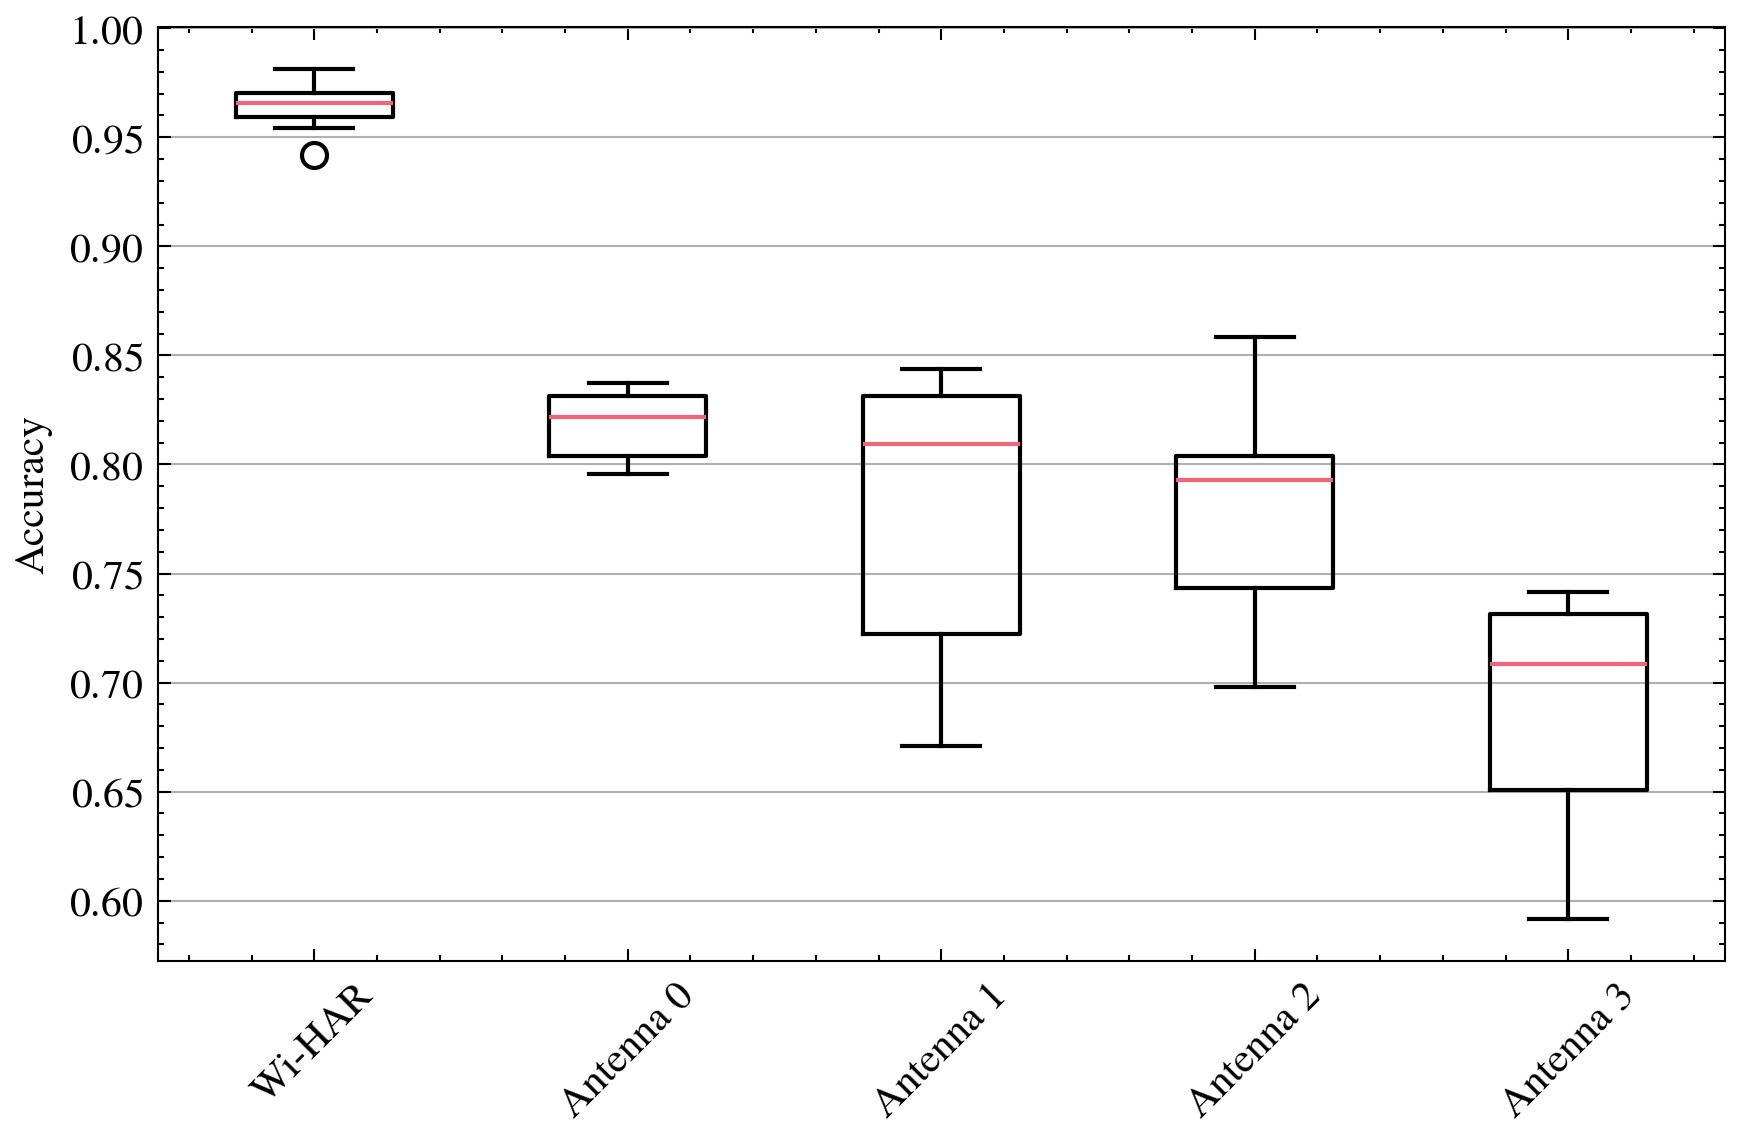

In [3]:
fusion_results = list(fusion_best_model.accuracies_per_seed.values())
single_results = [list(model.accuracies_per_seed.values()) for model in single_best_models]

data = [fusion_results] + [single_results[a] for a in range(len(single_results))]
labels = ["Wi-HAR"] + [f"Antenna {a}" for a in range(len(single_results))]

plt.figure(figsize=(6, 4))
plt.boxplot(data, tick_labels=labels)

plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis="y")
plt.savefig(PLOTS_DIR / "ablation.pdf")
plt.show()